In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
import pandas as pd
from matplotlib.patches import Rectangle, Patch
import matplotlib.patheffects as pe


def parse_benchmark_log(log_path):
    """从 benchmark.log 中提取关键 metrics，支持重复 benchmark block 并取均值。"""
    try:
        with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()

        ttft_values = [float(v) for v in re.findall(r'Mean TTFT \(ms\):\s+([\d.]+)', content)]
        itl_values = [float(v) for v in re.findall(r'Mean ITL \(ms\):\s+([\d.]+)', content)]
        tpot_values = [float(v) for v in re.findall(r'Mean TPOT \(ms\):\s+([\d.]+)', content)]
        throughput_values = [
            float(v)
            for v in re.findall(
                r'(?i)Total Token throughput \(tok/s\):\s+([\d.]+)',
                content,
            )
        ]

        if ttft_values and itl_values and tpot_values and throughput_values:
            return {
                'ttft': float(np.mean(ttft_values)),
                'itl': float(np.mean(itl_values)),
                'tpot': float(np.mean(tpot_values)),
                'throughput': float(np.mean(throughput_values)),
                'num_repetitions': min(
                    len(ttft_values),
                    len(itl_values),
                    len(tpot_values),
                    len(throughput_values),
                ),
            }
    except Exception as e:
        print(f"Error parsing {log_path}: {e}")

    return None


def sort_key(pp_config):
    """PP config排序key: 按prefill层数排序"""
    return int(pp_config.split('-')[0])

In [2]:


# ==================== 新数据：两种workload对比 ====================
LOG_DIR_NEW = "/home/bxb1/vllm_workbench/vllm/new-logs/project-config-finder-llama-latest-4"

def parse_folder_name_full(folder_name):
    """从文件夹名中提取pp config, request rate和workload类型"""
    pp_match = re.search(r'\{pp=(\d+-\d+)\}', folder_name)
    rr_match = re.search(r'\{rr=([\d.]+)\}', folder_name)
    in_match = re.search(r'\{in=(\d+)\}', folder_name)
    out_match = re.search(r'\{out=(\d+)\}', folder_name)
    
    if pp_match and rr_match and in_match and out_match:
        workload = f"in{in_match.group(1)}_out{out_match.group(1)}"
        return pp_match.group(1), float(rr_match.group(1)), workload
    return None, None, None

# 收集所有数据
data_all = []
for folder in os.listdir(LOG_DIR_NEW):
    folder_path = os.path.join(LOG_DIR_NEW, folder)
    if os.path.isdir(folder_path):
        benchmark_log = os.path.join(folder_path, "benchmark.log")
        if os.path.exists(benchmark_log):
            pp_config, request_rate, workload = parse_folder_name_full(folder)
            if pp_config and request_rate and workload:
                metrics = parse_benchmark_log(benchmark_log)
                if metrics:
                    data_all.append({
                        'pp_config': pp_config,
                        'request_rate': request_rate,
                        'workload': workload,
                        **metrics
                    })

df_all = pd.DataFrame(data_all)
print(f"收集到 {len(df_all)} 个实验数据点")
print(f"Workload类型: {df_all['workload'].unique()}")
print(f"PP Configs: {sorted(df_all['pp_config'].unique(), key=sort_key)}")
df_all.head(10)

收集到 96 个实验数据点
Workload类型: ['in512_out16' 'in128_out512']
PP Configs: ['36-44', '40-40', '44-36', '48-32', '52-28', '56-24', '60-20', '64-16']


,pp_config,request_rate,workload,ttft,itl,tpot,throughput,num_repetitions
0,40-40,0.5,in512_out16,422.196667,90.986667,97.053333,259.656667,3
1,60-20,3.0,in512_out16,8104.900000,1283.816667,1369.403333,1155.603333,3
2,40-40,2.0,in512_out16,472.310000,229.396667,244.693333,1008.100000,3
3,40-40,3.0,in128_out512,260.763333,143.403333,147.113333,416.383333,3
4,60-20,3.0,in128_out512,275.913333,131.310000,139.413333,470.230000,3
5,36-44,1.5,in512_out16,454.973333,159.433333,170.063333,763.313333,3
6,40-40,2.5,in512_out16,1527.186667,805.870000,859.593333,1213.693333,3
7,52-28,2.5,in512_out16,3252.726667,1204.540000,1284.846667,1141.493333,3
8,56-24,2.5,in512_out16,3854.246667,1294.456667,1380.750000,1125.810000,3
9,36-44,1.0,in512_out16,454.086667,124.100000,132.380000,514.050000,3


In [3]:
# 分离两种workload的数据
workloads = sorted(df_all['workload'].unique())
print("识别到的Workload类型:")
for w in workloads:
    count = len(df_all[df_all['workload'] == w])
    print(f"  - {w}: {count} 个数据点")

# 获取排序后的pp_configs和request_rates
pp_configs_all = sorted(df_all['pp_config'].unique(), key=sort_key)
rr_all = sorted(df_all['request_rate'].unique())
print(f"\nPP Configs: {pp_configs_all}")
print(f"Request Rates: {rr_all}")

识别到的Workload类型:
  - in128_out512: 48 个数据点
  - in512_out16: 48 个数据点

PP Configs: ['36-44', '40-40', '44-36', '48-32', '52-28', '56-24', '60-20', '64-16']
Request Rates: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]


PP_STEP = 8
筛选后的PP Configs (4个): ['36-44', '44-36', '52-28', '60-20']
图大小: 26x14.0, 标注字体: 22
TTFT 固定上限: {'in128_out512': 300, 'in512_out16': 550}
in128_out512 TTFT range: min=224.4, max=300
in512_out16 TTFT range: min=414.9, max=550
已保存: /home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-config-heatmap.pdf


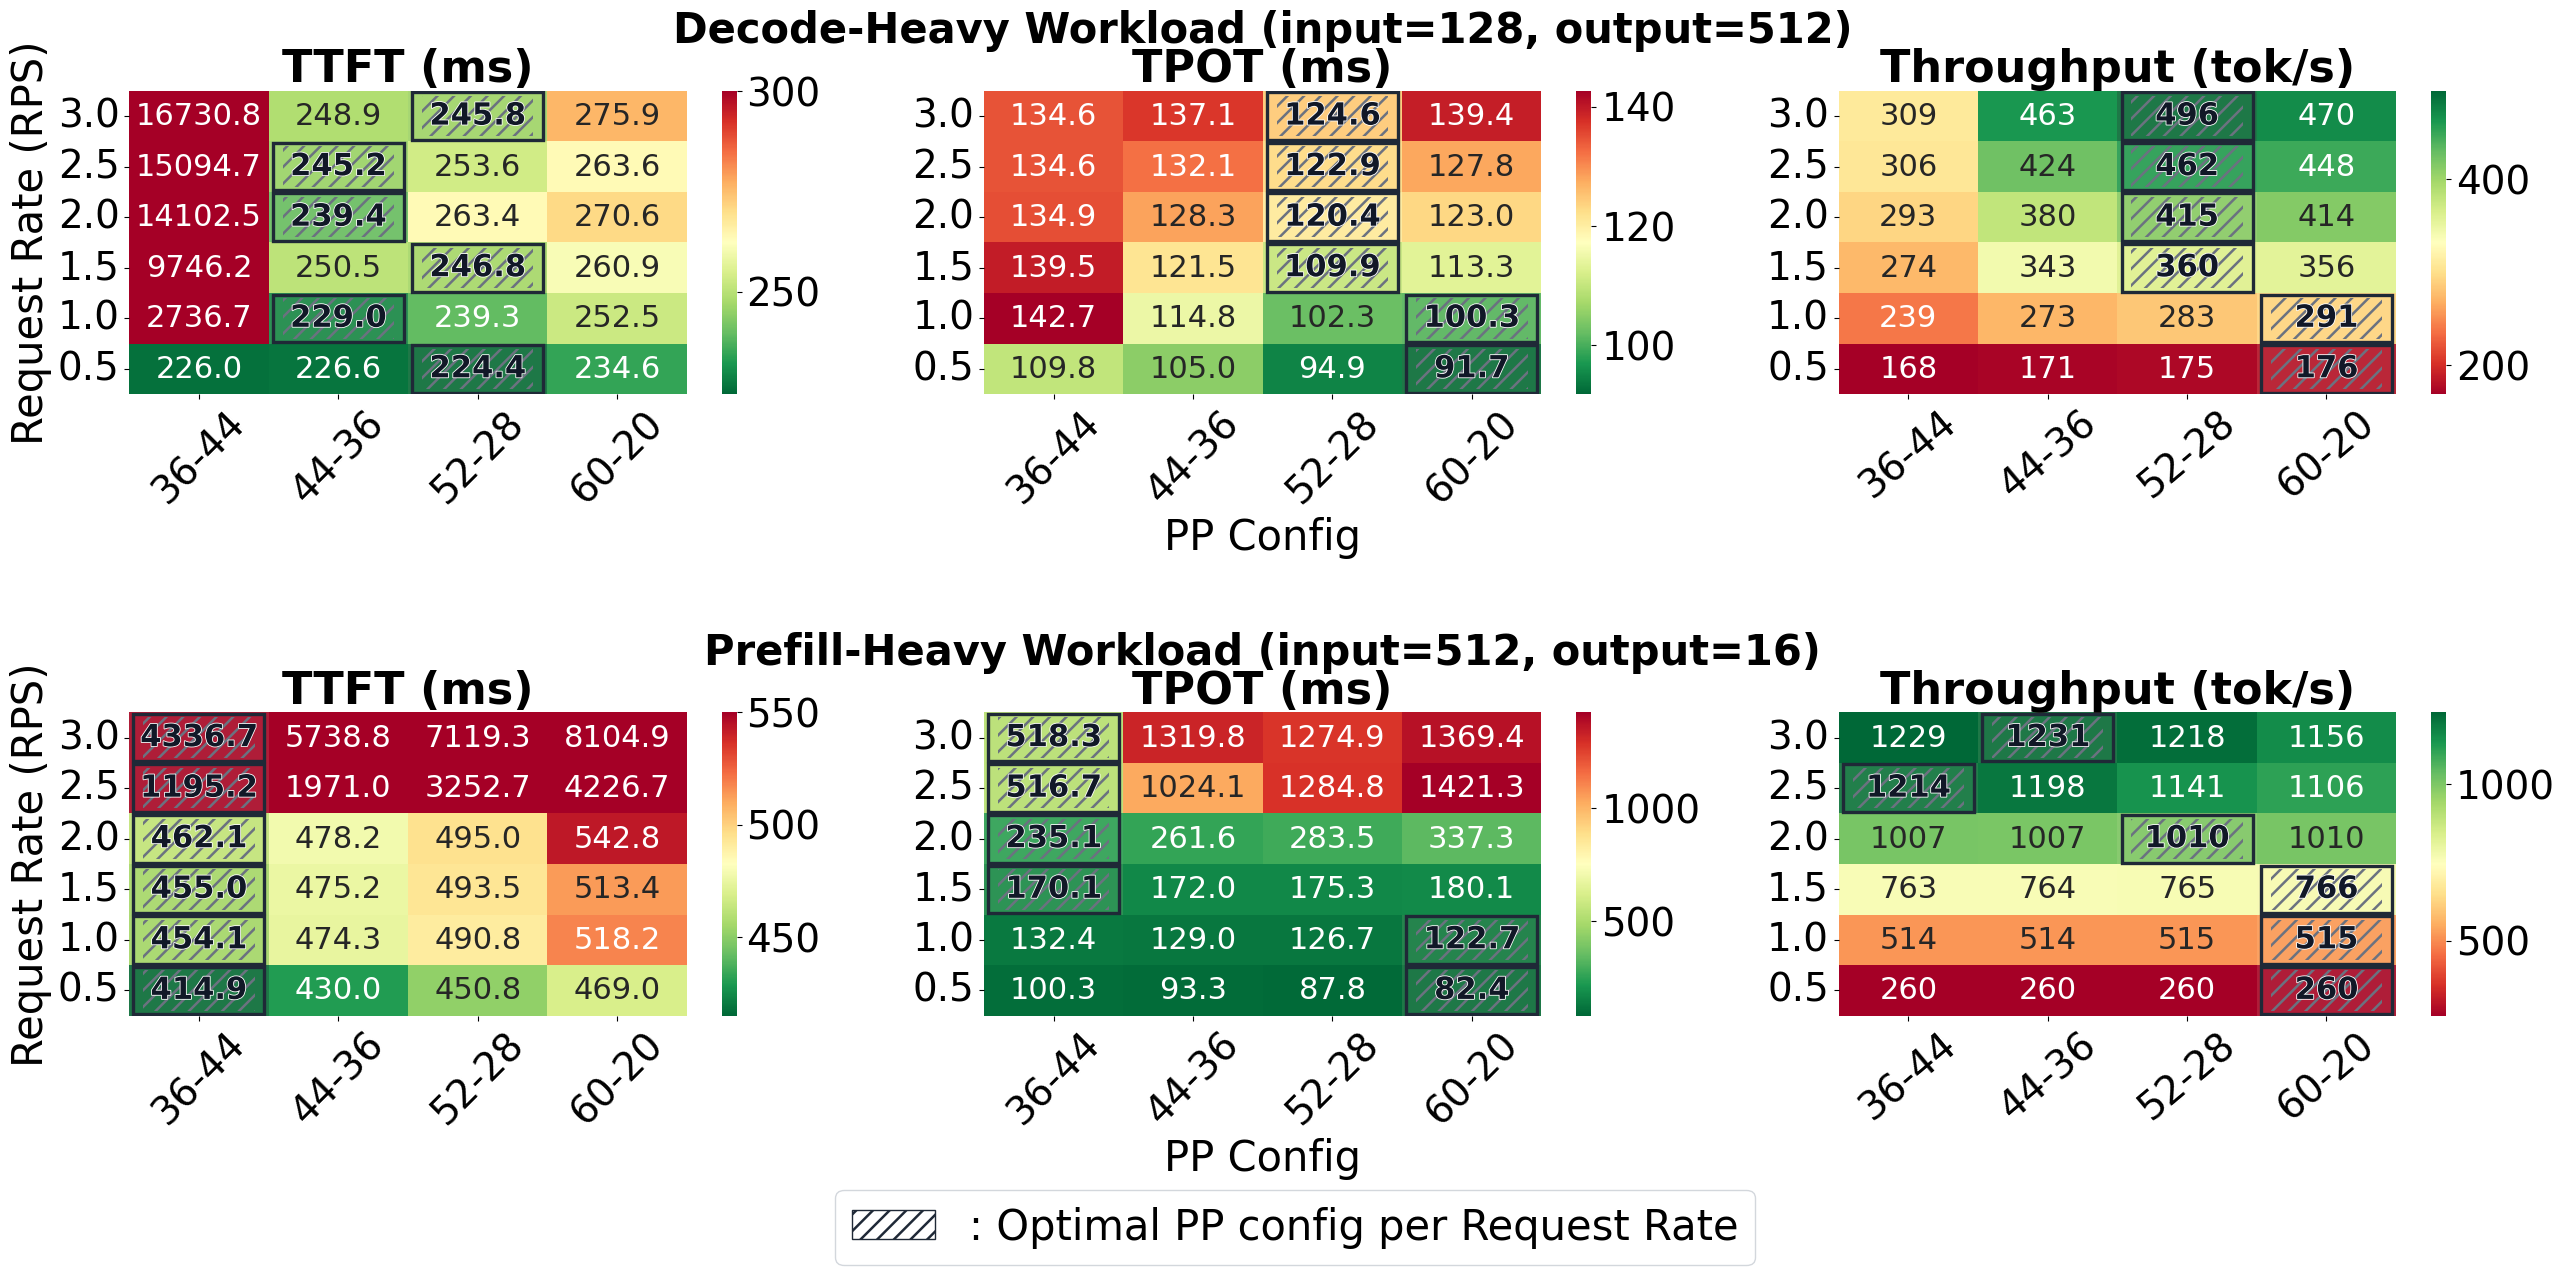

In [6]:
# 配置变量

from matplotlib.patches import Rectangle, Patch
import matplotlib.patheffects as pe

PP_STEP = 8  # 每隔几个layer显示一个config (可选: 2, 3 或 4)

# 根据step筛选pp_configs (从36开始)
def filter_pp_configs(configs, step):
    """从36-44开始，每隔step个layer选择一个config"""
    result = []
    for pp in configs:
        prefill = int(pp.split('-')[0])
        if (prefill - 36) % step == 0:
            result.append(pp)
    return result


OPTIMAL_FILL_COLOR = '#fff3bf'
OPTIMAL_BORDER_COLOR = '#1f2937'


def highlight_best_cells(ax, pivot_df, mode='max'):
    """高亮每个 request rate 对应的最优 PP config cell，并同步强化数值文本。"""
    values = pivot_df.to_numpy(dtype=float)
    text_lookup = {
        (round(text.get_position()[0], 3), round(text.get_position()[1], 3)): text
        for text in ax.texts
    }

    for row_idx in range(values.shape[0]):
        row = values[row_idx]
        valid_cols = np.where(~np.isnan(row))[0]
        if len(valid_cols) == 0:
            continue

        valid_values = row[valid_cols]
        best_value = np.nanmin(valid_values) if mode == 'min' else np.nanmax(valid_values)
        best_cols = valid_cols[np.isclose(valid_values, best_value, rtol=1e-5, atol=1e-8)]

        for best_col in best_cols:
            ax.add_patch(
                Rectangle(
                    (best_col, row_idx),
                    1,
                    1,
                    facecolor=OPTIMAL_FILL_COLOR,
                    edgecolor='none',
                    alpha=0.12,
                    zorder=8,
                )
            )
            ax.add_patch(
                Rectangle(
                    (best_col + 0.10, row_idx + 0.10),
                    0.80,
                    0.80,
                    facecolor='none',
                    edgecolor='#6b7280',
                    hatch='//',
                    linewidth=0.0,
                    zorder=9,
                )
            )
            ax.add_patch(
                Rectangle(
                    (best_col + 0.03, row_idx + 0.03),
                    0.94,
                    0.94,
                    fill=False,
                    edgecolor=OPTIMAL_BORDER_COLOR,
                    linewidth=2.4,
                    zorder=10,
                    joinstyle='miter',
                )
            )
            text = text_lookup.get((round(best_col + 0.5, 3), round(row_idx + 0.5, 3)))
            if text is not None and text.get_text():
                text.set_fontweight('semibold')
                text.set_color('#111827')
                text.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])
                text.set_zorder(13)


pp_configs_filtered = filter_pp_configs(pp_configs_all, PP_STEP)
print(f"PP_STEP = {PP_STEP}")
print(f"筛选后的PP Configs ({len(pp_configs_filtered)}个): {pp_configs_filtered}")

# 根据pp_configs数量动态调整图大小和字体 - 改为2行3列布局（每行一个workload）
n_configs = len(pp_configs_filtered)
base_fig_width = max(26, n_configs * 3.0)
fig_width = base_fig_width * 1.5 if PP_STEP == 4 else base_fig_width
fig_height = 14.0

# 字号设置
annot_fontsize = 22
title_fontsize = 32
axis_label_fontsize = 30
tick_fontsize = 28
suptitle_fontsize = 30
cbar_tick_fontsize = 28

fmt_ttft = '.1f' if n_configs <= 10 else '.0f'
fmt_tpot = '.1f' if n_configs <= 10 else '.0f'
fmt_thru = '.0f'

# TTFT 上限固定，下限按每个 workload 当前图中的实际最小值自动识别
ttft_vmax_by_workload = {
    'in128_out512': 300,
    'in512_out16': 550,
}

print(f"图大小: {fig_width}x{fig_height}, 标注字体: {annot_fontsize}")
print(f"TTFT 固定上限: {ttft_vmax_by_workload}")

# 定义每个workload显示的request rate范围
workload_rr_range = {
    'in128_out512': [0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
    'in512_out16': [0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
}

# 定义workload友好名称（用于行标题）
workload_titles = {
    'in128_out512': 'Decode-Heavy Workload (input=128, output=512)',
    'in512_out16': 'Prefill-Heavy Workload (input=512, output=16)',
}

# 确保workloads顺序: decode-heavy在上，prefill-heavy在下
workloads_ordered = ['in128_out512', 'in512_out16']

# 创建2行3列的合并图 (每个workload 3列: TTFT / TPOT / Throughput)
fig, axes = plt.subplots(2, 3, figsize=(fig_width, fig_height))
optimal_legend_handle = Patch(
    facecolor='none',
    edgecolor=OPTIMAL_BORDER_COLOR,
    hatch='//',
    label=': Optimal PP config per Request Rate',
)

for i, workload in enumerate(workloads_ordered):
    df_w = df_all[df_all['workload'] == workload]
    rr_range = workload_rr_range.get(workload, rr_all)
    rr_display = sorted(rr_range, reverse=True)

    # 创建 pivot tables
    ttft_pv = df_w.pivot_table(values='ttft', index='request_rate', columns='pp_config', aggfunc='mean')
    tpot_pv = df_w.pivot_table(values='tpot', index='request_rate', columns='pp_config', aggfunc='mean')
    thru_pv = df_w.pivot_table(values='throughput', index='request_rate', columns='pp_config', aggfunc='mean')

    # 重新排列：让图中从下到上 request rate 递增
    ttft_pv = ttft_pv.reindex(columns=pp_configs_filtered, index=rr_display)
    tpot_pv = tpot_pv.reindex(columns=pp_configs_filtered, index=rr_display)
    thru_pv = thru_pv.reindex(columns=pp_configs_filtered, index=rr_display)

    # 每个 workload 的 TTFT 下限使用该图可见数据中的实际最小值
    ttft_values = ttft_pv.to_numpy(dtype=float)
    ttft_vmin = float(np.nanmin(ttft_values))
    ttft_vmax = ttft_vmax_by_workload.get(workload, None)

    ax_ttft = axes[i, 0]
    ax_tpot = axes[i, 1]
    ax_tp = axes[i, 2]

    # TTFT 热力图
    sns.heatmap(
        ttft_pv, annot=True, fmt=fmt_ttft, cmap='RdYlGn_r', ax=ax_ttft,
        annot_kws={'size': annot_fontsize},
        vmin=ttft_vmin, vmax=ttft_vmax,
    )
    highlight_best_cells(ax_ttft, ttft_pv, mode='min')
    ax_ttft.set_title('TTFT (ms)', fontsize=title_fontsize, fontweight='bold')
    ax_ttft.set_xlabel('')
    ax_ttft.set_ylabel('Request Rate (RPS)', fontsize=axis_label_fontsize)
    ax_ttft.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
    ax_ttft.tick_params(axis='y', rotation=0, labelsize=tick_fontsize)
    ax_ttft.collections[0].colorbar.ax.tick_params(labelsize=cbar_tick_fontsize)
    print(f"{workload} TTFT range: min={ttft_vmin:.1f}, max={ttft_vmax}")

    # TPOT 热力图
    sns.heatmap(
        tpot_pv, annot=True, fmt=fmt_tpot, cmap='RdYlGn_r', ax=ax_tpot,
        annot_kws={'size': annot_fontsize},
    )
    highlight_best_cells(ax_tpot, tpot_pv, mode='min')
    ax_tpot.set_title('TPOT (ms)', fontsize=title_fontsize, fontweight='bold')
    ax_tpot.set_xlabel('PP Config', fontsize=axis_label_fontsize)
    ax_tpot.set_ylabel('')
    ax_tpot.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
    ax_tpot.tick_params(axis='y', rotation=0, labelsize=tick_fontsize)
    ax_tpot.collections[0].colorbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    # Throughput 热力图
    sns.heatmap(
        thru_pv, annot=True, fmt=fmt_thru, cmap='RdYlGn', ax=ax_tp,
        annot_kws={'size': annot_fontsize},
    )
    highlight_best_cells(ax_tp, thru_pv, mode='max')
    ax_tp.set_title('Throughput (tok/s)', fontsize=title_fontsize, fontweight='bold')
    ax_tp.set_xlabel('')
    ax_tp.set_ylabel('')
    ax_tp.tick_params(axis='x', rotation=40, labelsize=tick_fontsize)
    ax_tp.tick_params(axis='y', rotation=0, labelsize=tick_fontsize)
    ax_tp.collections[0].colorbar.ax.tick_params(labelsize=cbar_tick_fontsize)

legend_fontsize = 30 

plt.tight_layout(rect=[0, 0.08, 1, 0.91], h_pad=8.0, w_pad=3.0)

# 添加每行的小标题
for i, workload in enumerate(workloads_ordered):
    workload_title = workload_titles.get(workload, workload)
    row_left = axes[i, 0].get_position().x0
    row_right = axes[i, 2].get_position().x1
    row_top = axes[i, 0].get_position().y1
    center_x = (row_left + row_right) / 2
    fig.text(
        center_x, row_top + 0.028, workload_title, ha='center', va='bottom',
        fontsize=suptitle_fontsize, fontweight='bold'
    )

fig.legend(
    handles=[optimal_legend_handle],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.015),
    frameon=True,
    framealpha=0.95,
    edgecolor='#d1d5db',
    facecolor='white',
    fontsize=legend_fontsize,
)

# 保存合并后的单个文件
save_name = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-config-heatmap.pdf'
plt.savefig(save_name, format='pdf', bbox_inches='tight')
print(f"已保存: {save_name}")
plt.show()

全部 PP Configs: []
按 12 层单位显示的 6 个配置: []

Shown Prefill-Optimal config (TTFT): None
Shown Decode-Optimal config (TTFT): None


ValueError: max() iterable argument is empty

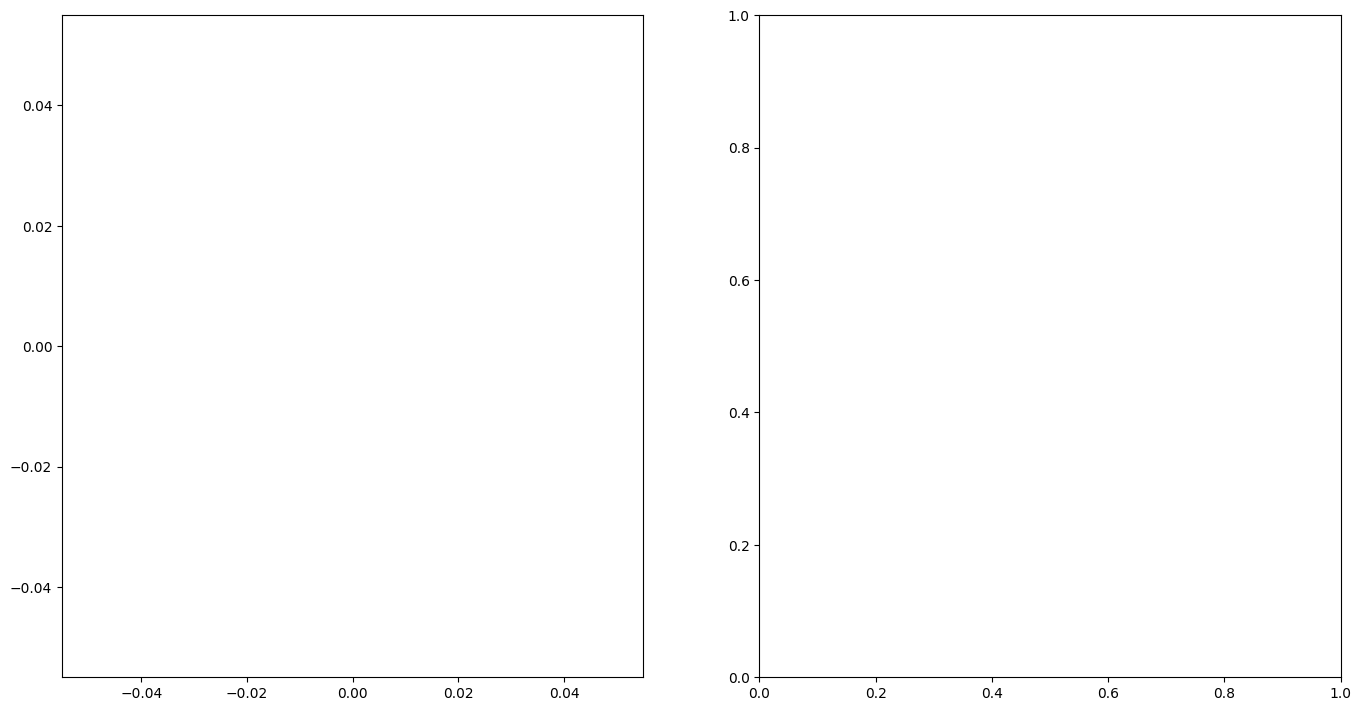

In [5]:
# ==================== 柱状图：Qwen 在 rr=5 时不同 PP Config 的 TTFT 对比 ====================
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
import re
from matplotlib.patches import Patch

LOG_DIR = "/home/bxb1/vllm_workbench/vllm/new-logs/project-config_finder_qwen-2"
TARGET_RR = 5.0
DISPLAY_UNIT = 12  # 以 12 层为一个单位显示
DISPLAY_COUNT = 6


def parse_ttft_all_reps(log_path):
    """提取每次重复的 TTFT 值，用于计算均值和标准差。"""
    try:
        with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
        values = [
            float(v)
            for v in re.findall(
                r'Mean TTFT \(ms\):\s+([\d.]+)',
                content,
            )
        ]
        return values if values else None
    except Exception:
        return None


def parse_folder(name):
    pp = re.search(r'\{pp=(\d+-\d+)\}', name)
    rr = re.search(r'\{rr=([\d.]+)\}', name)
    inp = re.search(r'\{in=(\d+)\}', name)
    out = re.search(r'\{out=(\d+)\}', name)
    if pp and rr and inp and out:
        return pp.group(1), float(rr.group(1)), f"in{inp.group(1)}_out{out.group(1)}"
    return None, None, None


def sort_key(pp_config):
    return int(pp_config.split('-')[0])


def format_pp_label(pp_config):
    l40s, a100 = pp_config.split('-')
    return f"{l40s}/{a100}"


def select_display_pp_configs(all_configs, unit=12, total_count=6):
    """按 prefill 层数每隔 unit 选择一个配置，并确保总数为 total_count。"""
    sorted_configs = sorted(all_configs, key=sort_key)
    if not sorted_configs:
        return []

    min_prefill = sort_key(sorted_configs[0])
    selected = []
    for pp in sorted_configs:
        prefill = sort_key(pp)
        if (prefill - min_prefill) % unit == 0:
            selected.append(pp)

    if sorted_configs[-1] not in selected:
        selected.append(sorted_configs[-1])

    selected = sorted(set(selected), key=sort_key)

    if len(selected) > total_count:
        selected = selected[: total_count - 1] + [selected[-1]]
    elif len(selected) < total_count:
        for pp in reversed(sorted_configs):
            if pp not in selected:
                selected.append(pp)
            if len(selected) == total_count:
                break
        selected = sorted(selected, key=sort_key)

    return selected


# 收集 rr=5 的 TTFT 数据
data = {}
for folder in os.listdir(LOG_DIR):
    folder_path = os.path.join(LOG_DIR, folder)
    if not os.path.isdir(folder_path) or not folder.startswith('test-'):
        continue
    pp_config, rr, workload = parse_folder(folder)
    if pp_config and rr == TARGET_RR and workload:
        log_path = os.path.join(folder_path, 'benchmark.log')
        if os.path.exists(log_path):
            vals = parse_ttft_all_reps(log_path)
            if vals:
                data.setdefault(workload, {})[pp_config] = vals

all_pp_configs = sorted(set().union(*(d.keys() for d in data.values())), key=sort_key)
pp_configs = select_display_pp_configs(all_pp_configs, unit=DISPLAY_UNIT, total_count=DISPLAY_COUNT)

print(f"全部 PP Configs: {all_pp_configs}")
print(f"按 {DISPLAY_UNIT} 层单位显示的 {DISPLAY_COUNT} 个配置: {pp_configs}")
for workload, d in data.items():
    print(f"  {workload}: {sorted(d.keys(), key=sort_key)}")

workload_info = {
    'in512_out16': {
        'title': 'Prefill-Heavy Workload\ninput=512, output=16',
        'label': 'Prefill-Optimal',
    },
    'in128_out512': {
        'title': 'Decode-Heavy Workload\ninput=128, output=512',
        'label': 'Decode-Optimal',
    },
}
workloads_ordered = ['in512_out16', 'in128_out512']

# 更和谐的三色搭配：蓝灰 / 墨绿 / 酒红
static_color = '#8DA0BC'
prefill_opt_color = '#4C8C7A'
decode_opt_color = '#B46A78'

LABEL_FONT_SIZE = 22
XTICK_FONT_SIZE = 22
XLABEL_FONT_SIZE = 31
LEGEND_FONT_SIZE = 26
TITLE_FONT_SIZE = 30

# 在“当前显示的 6 个配置”里分别寻找两个 workload 的最优配置（TTFT 越小越好）
shown_best_pp_map = {}
for wl in workloads_ordered:
    d = data.get(wl, {})
    valid_display_pps = [pp for pp in pp_configs if pp in d]
    if valid_display_pps:
        shown_best_pp_map[wl] = min(valid_display_pps, key=lambda pp: np.mean(d[pp]))

prefill_best_pp = shown_best_pp_map.get('in512_out16')
decode_best_pp = shown_best_pp_map.get('in128_out512')
print(f"\nShown Prefill-Optimal config (TTFT): {prefill_best_pp}")
print(f"Shown Decode-Optimal config (TTFT): {decode_best_pp}")

mpl.rcParams['hatch.linewidth'] = 1.8
mpl.rcParams['hatch.color'] = 'black'

fig, axes = plt.subplots(1, 2, figsize=(16.5, 8.6))

for ax, workload in zip(axes, workloads_ordered):
    info = workload_info[workload]
    d = data.get(workload, {})

    means = [np.mean(d[pp]) if pp in d else np.nan for pp in pp_configs]
    stds = [np.std(d[pp]) if pp in d else 0 for pp in pp_configs]

    x = np.arange(len(pp_configs))
    bars = ax.bar(
        x,
        np.nan_to_num(means, nan=0.0),
        yerr=stds,
        color=static_color,
        edgecolor='#1f2937',
        linewidth=1.4,
        width=0.72,
        capsize=4,
        error_kw={'linewidth': 1.5, 'color': '#333333'},
    )

    prefill_idx = pp_configs.index(prefill_best_pp) if prefill_best_pp in pp_configs else None
    decode_idx = pp_configs.index(decode_best_pp) if decode_best_pp in pp_configs else None

    if prefill_idx is not None and not np.isnan(means[prefill_idx]):
        bars[prefill_idx].set_facecolor(prefill_opt_color)
        bars[prefill_idx].set_hatch('/')
        bars[prefill_idx].set_edgecolor('#111111')
        bars[prefill_idx].set_linewidth(1.7)

    if decode_idx is not None and not np.isnan(means[decode_idx]):
        bars[decode_idx].set_facecolor(decode_opt_color)
        bars[decode_idx].set_hatch('\\')
        bars[decode_idx].set_edgecolor('#111111')
        bars[decode_idx].set_linewidth(1.7)

    valid_means = [m for m in means if not np.isnan(m)]
    valid_stds = [s for m, s in zip(means, stds) if not np.isnan(m)]
    ymin = 0
    ymax = max(valid_means) + (max(valid_stds) if valid_stds else 0) * 1.9 + 80
    ax.set_ylim(ymin, ymax)

    for idx, (mean, std) in enumerate(zip(means, stds)):
        if np.isnan(mean):
            continue
        ax.text(
            idx,
            mean + std + ymax * 0.015,
            f"{mean:.0f}",
            ha='center',
            va='bottom',
            fontsize=LABEL_FONT_SIZE - 4,
            fontweight='semibold',
            rotation=0,
        )

    ax.set_title(info['title'], fontsize=TITLE_FONT_SIZE, fontweight='bold', pad=24)
    ax.set_ylabel('TTFT (ms)', fontsize=24, fontweight='bold', labelpad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [format_pp_label(pp) for pp in pp_configs],
        rotation=45,
        ha='right',
        rotation_mode='anchor',
        fontsize=XTICK_FONT_SIZE,
    )
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', pad=6)
    ax.grid(axis='y', linestyle='--', alpha=0.28)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.1)
    ax.spines['bottom'].set_linewidth(1.1)

fig.supxlabel(
    'PP Configuration (L40s/A100 layers)',
    fontsize=XLABEL_FONT_SIZE,
    fontweight='bold',
    y=0.23,
)

legend_handles = [
    Patch(facecolor=prefill_opt_color, edgecolor='#111111', hatch='/', label='Prefill-Optimal'),
    Patch(facecolor=decode_opt_color, edgecolor='#111111', hatch='\\', label='Decode-Optimal'),
    Patch(facecolor=static_color, edgecolor='#1f2937', label='Other configs'),
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    fontsize=LEGEND_FONT_SIZE,
    frameon=True,
    edgecolor='#bbbbbb',
    bbox_to_anchor=(0.5, 0.105),
    columnspacing=1.8,
    handletextpad=0.7,
    borderpad=0.35,
    labelspacing=0.5,
)

plt.subplots_adjust(left=0.08, right=0.99, bottom=0.41, top=0.85, wspace=0.25)

save_path = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/flexiserve-motivation-ttft-rr5.pdf'
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"已保存: {save_path}")
plt.show()

In [ ]:
# ==================== Best Config 跨 Workload 性能差距分析 ====================

print("=" * 72)
print("Best Config 跨 Workload 性能差距分析 (rr=5)")
print("=" * 72)

# 找到每个 workload 的 best config
best_configs = {}
for workload in workloads_ordered:
    d = data.get(workload, {})
    if not d:
        continue
    best_pp = max(d.keys(), key=lambda pp: np.mean(d[pp]))
    best_mean = np.mean(d[best_pp])
    best_configs[workload] = {'pp': best_pp, 'throughput': best_mean}
    wl_label = workload_info[workload]['title'].split('\n')[0]
    print(f"\n{wl_label}:")
    print(f"  Best PP Config: {best_pp}  →  Throughput: {best_mean:.1f} tok/s")

# 交叉对比：用 A 的 best config 跑 B 的 workload
print("\n" + "-" * 72)
print("交叉对比：用一个 workload 的 best config 跑另一个 workload")
print("-" * 72)

for src_wl in workloads_ordered:
    for tgt_wl in workloads_ordered:
        if src_wl == tgt_wl:
            continue
        src_label = workload_info[src_wl]['title'].split('\n')[0]
        tgt_label = workload_info[tgt_wl]['title'].split('\n')[0]
        src_best_pp = best_configs[src_wl]['pp']
        tgt_best_pp = best_configs[tgt_wl]['pp']
        tgt_best_tp = best_configs[tgt_wl]['throughput']

        # src 的 best config 在 tgt workload 上的表现
        tgt_data = data.get(tgt_wl, {})
        if src_best_pp in tgt_data:
            cross_tp = np.mean(tgt_data[src_best_pp])
            gap = (tgt_best_tp - cross_tp) / tgt_best_tp * 100
            print(f"\n用 {src_label} 的 best config ({src_best_pp}) 跑 {tgt_label}:")
            print(f"  Throughput: {cross_tp:.1f} tok/s  (该 workload 最优: {tgt_best_tp:.1f} tok/s, config={tgt_best_pp})")
            print(f"  性能损失: {gap:.1f}%")
        else:
            print(f"\n用 {src_label} 的 best config ({src_best_pp}) 跑 {tgt_label}: 无数据")


Best Config 跨 Workload 性能差距分析 (rr=5)

Prefill-Heavy Workload:
  Best PP Config: 12-52  →  Throughput: 2505.8 tok/s

Decode-Heavy Workload:
  Best PP Config: 44-20  →  Throughput: 1090.7 tok/s

------------------------------------------------------------------------
交叉对比：用一个 workload 的 best config 跑另一个 workload
------------------------------------------------------------------------

用 Prefill-Heavy Workload 的 best config (12-52) 跑 Decode-Heavy Workload:
  Throughput: 769.2 tok/s  (该 workload 最优: 1090.7 tok/s, config=44-20)
  性能损失: 29.5%

用 Decode-Heavy Workload 的 best config (44-20) 跑 Prefill-Heavy Workload:
  Throughput: 1907.0 tok/s  (该 workload 最优: 2505.8 tok/s, config=12-52)
  性能损失: 23.9%


收集到 150 个实验数据点
Workload 类型: ['in128_out512', 'in512_out16']
PP Configs: ['4-60', '8-56', '12-52', '16-48', '20-44', '24-40', '28-36', '32-32', '36-28', '40-24', '44-20', '48-16', '52-12', '56-8', '60-4']
Request Rates: [1.0, 2.0, 3.0, 4.0, 5.0]
PP_STEP = 4
筛选后的 PP Configs (15 个): ['4-60', '8-56', '12-52', '16-48', '20-44', '24-40', '28-36', '32-32', '36-28', '40-24', '44-20', '48-16', '52-12', '56-8', '60-4']


/tmp/ipykernel_128917/3638754285.py:73: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: '' if pd.isna(x) else (f"{x/1000:.1f}k" if x >= 1000 else f"{x:.0f}"))
/tmp/ipykernel_128917/3638754285.py:83: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(_fmt)
/tmp/ipykernel_128917/3638754285.py:87: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: '' if pd.isna(x) else f"{x:.0f}")
/tmp/ipykernel_128917/3638754285.py:73: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: '' if pd.isna(x) else (f"{x/1000:.1f}k" if x >= 1000 else f"{x:.0f}"))
/tmp/ipykernel_128917/3638754285.py:83: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(_fmt)
/tmp/ipykernel_128917/3638754285.py:87: FutureWarning: DataFrame.ap

已保存: /home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-config-heatmap-qwen-step4-with-ttft-2rows-readable.pdf


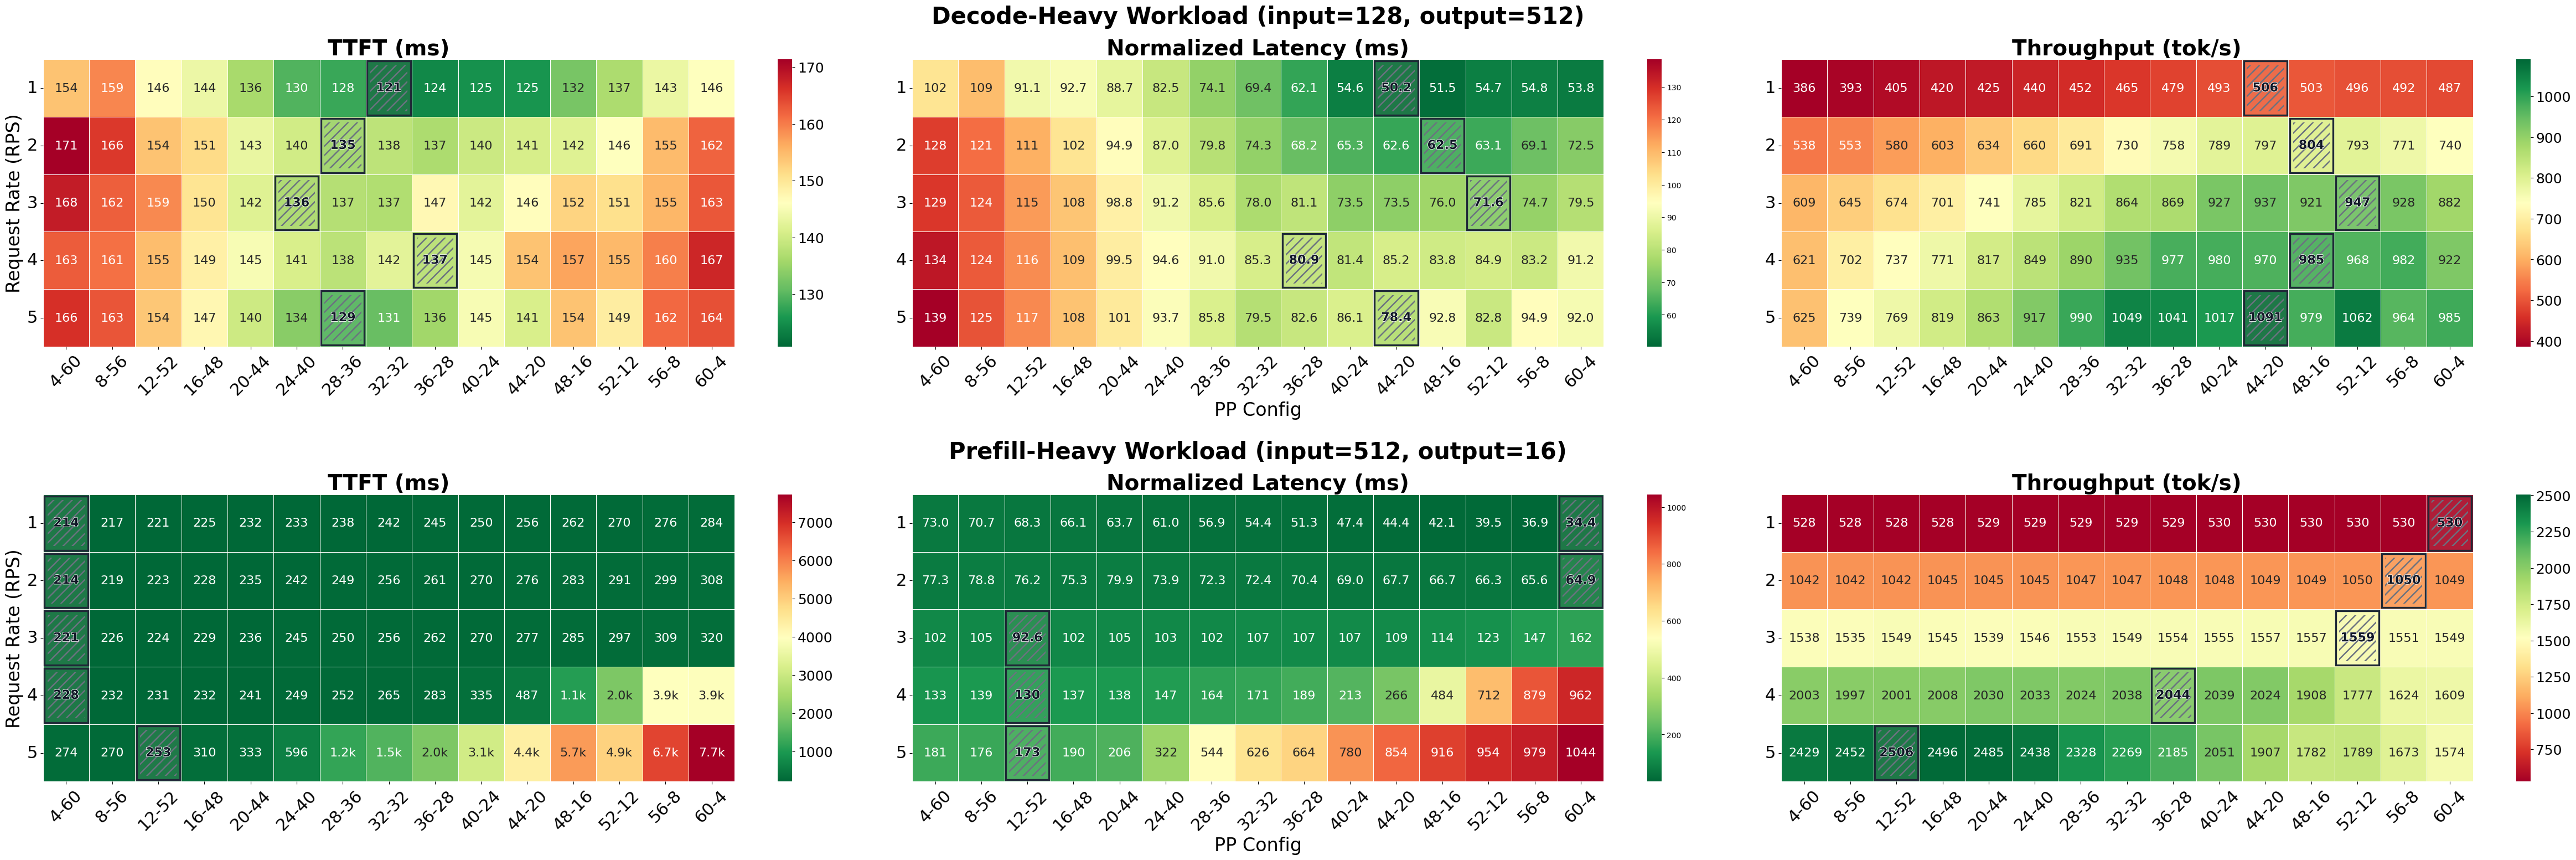

In [ ]:
# ==================== Qwen 数据：两种 workload 对比 ====================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
import pandas as pd
from matplotlib.patches import Rectangle, Patch
import matplotlib.patheffects as pe

LOG_DIR_QWEN = "/home/bxb1/vllm_workbench/vllm/new-logs/project-config_finder_qwen-1"
SAVE_NAME_QWEN = "/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-config-heatmap-qwen-step4-with-ttft-2rows-readable.pdf"


def parse_benchmark_log_local(log_path):
    """从 benchmark.log 中提取关键 metrics，支持重复 benchmark block 并取均值。"""
    try:
        with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()

        ttft_values = [float(v) for v in re.findall(r'Mean TTFT \(ms\):\s+([\d.]+)', content)]
        tpot_values = [float(v) for v in re.findall(r'Mean TPOT \(ms\):\s+([\d.]+)', content)]
        throughput_values = [
            float(v)
            for v in re.findall(
                r'(?i)Total Token throughput \(tok/s\):\s+([\d.]+)',
                content,
            )
        ]

        if ttft_values and tpot_values and throughput_values:
            return {
                'ttft': float(np.mean(ttft_values)),
                'tpot': float(np.mean(tpot_values)),
                'throughput': float(np.mean(throughput_values)),
                'num_repetitions': min(
                    len(ttft_values), len(tpot_values), len(throughput_values)
                ),
            }
    except Exception as e:
        print(f"Error parsing {log_path}: {e}")
    return None


def parse_folder_name_full_local(folder_name):
    """从文件夹名中提取 pp config、request rate 和 workload 类型"""
    pp_match = re.search(r'\{pp=(\d+-\d+)\}', folder_name)
    rr_match = re.search(r'\{rr=([\d.]+)\}', folder_name)
    in_match = re.search(r'\{in=(\d+)\}', folder_name)
    out_match = re.search(r'\{out=(\d+)\}', folder_name)

    if pp_match and rr_match and in_match and out_match:
        workload = f"in{in_match.group(1)}_out{out_match.group(1)}"
        return pp_match.group(1), float(rr_match.group(1)), workload
    return None, None, None


def sort_key_local(pp_config):
    return int(pp_config.split('-')[0])


def filter_pp_configs_local(configs, step):
    """按 prefill 层数每隔 step 选择一个 config"""
    result = []
    for pp in configs:
        prefill = int(pp.split('-')[0])
        if (prefill - 4) % step == 0:
            result.append(pp)
    return result


def format_ttft_annot(df):
    return df.applymap(lambda x: '' if pd.isna(x) else (f"{x/1000:.1f}k" if x >= 1000 else f"{x:.0f}"))


def format_tpot_annot(df):
    def _fmt(x):
        if pd.isna(x):
            return ''
        if x >= 100:
            return f"{x:.0f}"
        return f"{x:.1f}"
    return df.applymap(_fmt)


def format_thru_annot(df):
    return df.applymap(lambda x: '' if pd.isna(x) else f"{x:.0f}")


OPTIMAL_FILL_COLOR = '#fff3bf'
OPTIMAL_BORDER_COLOR = '#1f2937'


def highlight_best_cells(ax, pivot_df, mode='max'):
    """高亮每个 request rate 对应的最优 PP config cell，并同步强化数值文本。"""
    values = pivot_df.to_numpy(dtype=float)
    text_lookup = {
        (round(text.get_position()[0], 3), round(text.get_position()[1], 3)): text
        for text in ax.texts
    }

    for row_idx in range(values.shape[0]):
        row = values[row_idx]
        valid_cols = np.where(~np.isnan(row))[0]
        if len(valid_cols) == 0:
            continue

        valid_values = row[valid_cols]
        best_value = np.nanmin(valid_values) if mode == 'min' else np.nanmax(valid_values)
        best_cols = valid_cols[np.isclose(valid_values, best_value, rtol=1e-5, atol=1e-8)]

        for best_col in best_cols:
            ax.add_patch(
                Rectangle(
                    (best_col, row_idx),
                    1,
                    1,
                    facecolor=OPTIMAL_FILL_COLOR,
                    edgecolor='none',
                    alpha=0.12,
                    zorder=8,
                )
            )
            ax.add_patch(
                Rectangle(
                    (best_col + 0.10, row_idx + 0.10),
                    0.80,
                    0.80,
                    facecolor='none',
                    edgecolor='#6b7280',
                    hatch='//',
                    linewidth=0.0,
                    zorder=9,
                )
            )
            ax.add_patch(
                Rectangle(
                    (best_col + 0.03, row_idx + 0.03),
                    0.94,
                    0.94,
                    fill=False,
                    edgecolor=OPTIMAL_BORDER_COLOR,
                    linewidth=2.4,
                    zorder=10,
                    joinstyle='miter',
                )
            )

            text = text_lookup.get((round(best_col + 0.5, 3), round(row_idx + 0.5, 3)))
            if text is not None and text.get_text():
                text.set_fontweight('semibold')
                text.set_color('#111827')
                text.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])
                text.set_zorder(13)


data_qwen = []
for folder in os.listdir(LOG_DIR_QWEN):
    folder_path = os.path.join(LOG_DIR_QWEN, folder)
    if not os.path.isdir(folder_path) or not folder.startswith('test-'):
        continue
    benchmark_log = os.path.join(folder_path, 'benchmark.log')
    if not os.path.exists(benchmark_log):
        continue
    pp_config, request_rate, workload = parse_folder_name_full_local(folder)
    if pp_config and request_rate and workload:
        metrics = parse_benchmark_log_local(benchmark_log)
        if metrics:
            data_qwen.append({
                'pp_config': pp_config,
                'request_rate': request_rate,
                'workload': workload,
                **metrics,
            })

df_qwen = pd.DataFrame(data_qwen)
print(f"收集到 {len(df_qwen)} 个实验数据点")
print(f"Workload 类型: {sorted(df_qwen['workload'].unique())}")

pp_configs_qwen = sorted(df_qwen['pp_config'].unique(), key=sort_key_local)
rr_qwen = sorted(df_qwen['request_rate'].unique())
print(f"PP Configs: {pp_configs_qwen}")
print(f"Request Rates: {rr_qwen}")

PP_STEP = 4
pp_configs_filtered_qwen = filter_pp_configs_local(pp_configs_qwen, PP_STEP)
print(f"PP_STEP = {PP_STEP}")
print(f"筛选后的 PP Configs ({len(pp_configs_filtered_qwen)} 个): {pp_configs_filtered_qwen}")

n_configs = len(pp_configs_filtered_qwen)
fig_width = max(32, n_configs * 3.2)
fig_height = 16.0

annot_fontsize = 16
title_fontsize = 28
axis_label_fontsize = 24
tick_fontsize = 22
suptitle_fontsize = 30
cbar_tick_fontsize = 18

workload_rr_range = {
    'in128_out512': [1, 2, 3, 4, 5],
    'in512_out16': [1, 2, 3, 4, 5],
}

workload_titles = {
    'in128_out512': 'Decode-Heavy Workload (input=128, output=512)',
    'in512_out16': 'Prefill-Heavy Workload (input=512, output=16)',
}

workloads_ordered = ['in128_out512', 'in512_out16']

fig, axes = plt.subplots(2, 3, figsize=(fig_width, fig_height))

for i, workload in enumerate(workloads_ordered):
    df_w = df_qwen[df_qwen['workload'] == workload]
    rr_range = workload_rr_range.get(workload, rr_qwen)

    ttft_pv = df_w.pivot_table(values='ttft', index='request_rate', columns='pp_config', aggfunc='mean')
    tpot_pv = df_w.pivot_table(values='tpot', index='request_rate', columns='pp_config', aggfunc='mean')
    thru_pv = df_w.pivot_table(values='throughput', index='request_rate', columns='pp_config', aggfunc='mean')

    ttft_pv = ttft_pv.reindex(columns=pp_configs_filtered_qwen, index=rr_range)
    tpot_pv = tpot_pv.reindex(columns=pp_configs_filtered_qwen, index=rr_range)
    thru_pv = thru_pv.reindex(columns=pp_configs_filtered_qwen, index=rr_range)

    ttft_annot = format_ttft_annot(ttft_pv)
    tpot_annot = format_tpot_annot(tpot_pv)
    thru_annot = format_thru_annot(thru_pv)

    ax_ttft = axes[i, 0]
    ax_nl = axes[i, 1]
    ax_tp = axes[i, 2]

    sns.heatmap(
        ttft_pv, annot=ttft_annot, fmt='', cmap='RdYlGn_r', ax=ax_ttft,
        linewidths=0.5, linecolor='white',
        annot_kws={'size': annot_fontsize}
    )
    highlight_best_cells(ax_ttft, ttft_pv, mode='min')
    ax_ttft.set_title('TTFT (ms)', fontsize=title_fontsize, fontweight='bold')
    ax_ttft.set_xlabel('')
    ax_ttft.set_ylabel('Request Rate (RPS)', fontsize=axis_label_fontsize)
    ax_ttft.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
    ax_ttft.tick_params(axis='y', rotation=0, labelsize=tick_fontsize)
    ax_ttft.collections[0].colorbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    sns.heatmap(
        tpot_pv, annot=tpot_annot, fmt='', cmap='RdYlGn_r', ax=ax_nl,
        linewidths=0.5, linecolor='white',
        annot_kws={'size': annot_fontsize}
    )
    highlight_best_cells(ax_nl, tpot_pv, mode='min')
    ax_nl.set_title('Normalized Latency (ms)', fontsize=title_fontsize, fontweight='bold')
    ax_nl.set_xlabel('PP Config', fontsize=axis_label_fontsize)
    ax_nl.set_ylabel('')
    ax_nl.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
    ax_nl.tick_params(axis='y', rotation=0, labelsize=tick_fontsize)

    sns.heatmap(
        thru_pv, annot=thru_annot, fmt='', cmap='RdYlGn', ax=ax_tp,
        linewidths=0.5, linecolor='white',
        annot_kws={'size': annot_fontsize}
    )
    highlight_best_cells(ax_tp, thru_pv, mode='max')
    ax_tp.set_title('Throughput (tok/s)', fontsize=title_fontsize, fontweight='bold')
    ax_tp.set_xlabel('')
    ax_tp.set_ylabel('')
    ax_tp.tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
    ax_tp.tick_params(axis='y', rotation=0, labelsize=tick_fontsize)
    ax_tp.collections[0].colorbar.ax.tick_params(labelsize=cbar_tick_fontsize)

plt.tight_layout(rect=[0, 0, 1, 0.94], w_pad=3.0, h_pad=7.0)

for i, workload in enumerate(workloads_ordered):
    workload_title = workload_titles.get(workload, workload)
    row_left = axes[i, 0].get_position().x0
    row_right = axes[i, 2].get_position().x1
    row_top = axes[i, 0].get_position().y1
    center_x = (row_left + row_right) / 2
    fig.text(
        center_x, row_top + 0.035, workload_title, ha='center', va='bottom',
        fontsize=suptitle_fontsize, fontweight='bold'
    )

plt.savefig(SAVE_NAME_QWEN, format='pdf', bbox_inches='tight')
print(f"已保存: {SAVE_NAME_QWEN}")
plt.show()